# Volleyball Rally Outcome Prediction

Baseline feedforward ANN for predicting the rally winner from the VREN dataset.

This notebook currently uses a **row-level baseline**:
- each row is treated as one independent training example
- rows with the same `rally` value are **not** grouped together yet
- so this is a baseline on event/state rows, not a full rally-sequence model

Workflow:
- load `dataset_full.csv`
- remove target-leaking columns
- convert all input columns to categorical features
- one-hot encode the inputs
- create stratified train/validation/test splits
- train a simple PyTorch MLP baseline
- report accuracy, ROC-AUC, and a confusion matrix


In [56]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [57]:
data_path = Path("dataset_full.csv")
assert data_path.exists(), f"Could not find {data_path.resolve()}"

df = pd.read_csv(data_path)
print(df.shape)
df.head()


(2429, 18)


,rally,round,team,receive_location,digger_location,pass_land_location,hitter_location,hit_land_location,pass_rating,set_type,set_location,hit_type,num_blockers,block_touch,serve_type,win_reason,lose_reason,winning_team
0,1,1.0,b,4.0,4.0,13.0,13.0,7.0,in,in,quick,off_speed,2.0,no,jump,NaN,NaN,a
1,1,2.0,a,7.0,6.0,3.0,11.0,17.0,out,out,oppo,hit,3.0,no,NaN,NaN,NaN,a
2,1,3.0,b,6.0,6.0,21.0,25.0,13.0,out,out,outside,free_ball,0.0,no,NaN,NaN,NaN,a
3,1,4.0,a,13.0,13.0,13.0,15.0,4.0,in,in,outside,hit,1.0,no,NaN,NaN,NaN,a
4,1,5.0,b,9.0,9.0,3.0,15.0,4.0,out,out,outside,hit,3.0,yes,NaN,NaN,NaN,a


In [58]:
# `winning_team` is the target. `win_reason` and `lose_reason` are removed
# because they directly reveal who won the point.
TARGET_COL = "winning_team"
LEAKY_COLS = ["win_reason", "lose_reason"]

feature_df = df.drop(columns=LEAKY_COLS + [TARGET_COL]).copy()
target_raw = df[TARGET_COL].astype(str).str.strip().str.lower()

label_map = {label: idx for idx, label in enumerate(sorted(target_raw.unique()))}
y = target_raw.map(label_map).astype(np.float32)

# Baseline choice: treat every remaining column as categorical.
# Missing values are replaced up front, then all values are cast to regular
# Python strings so sklearn sees a consistent input type.
feature_df = feature_df.fillna("missing").astype(str)
categorical_cols = feature_df.columns.tolist()

print("Label map:", label_map)
print("Categorical feature count:", len(categorical_cols))
print("Missing values remaining after fill:")
feature_df.isna().sum().sort_values(ascending=False).head(10)


Label map: {'a': 0, 'b': 1}
Categorical feature count: 15
Missing values remaining after fill:


rally                 0
round                 0
team                  0
receive_location      0
digger_location       0
pass_land_location    0
hitter_location       0
hit_land_location     0
pass_rating           0
set_type              0
dtype: int64

In [59]:
# Split rows into train / validation / test.
# Important: this is a row-level split, not a rally-level grouped split.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    feature_df,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1764705882,  # gives 70/15/15 overall
    random_state=SEED,
    stratify=y_train_full,
)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("cat", onehot, categorical_cols),
], remainder="drop")

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_np = preprocessor.transform(X_val).astype(np.float32)
X_test_np = preprocessor.transform(X_test).astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("Train shape:", X_train_np.shape)
print("Val shape:", X_val_np.shape)
print("Test shape:", X_test_np.shape)


Train shape: (1699, 379)
Val shape: (365, 379)
Test shape: (365, 379)


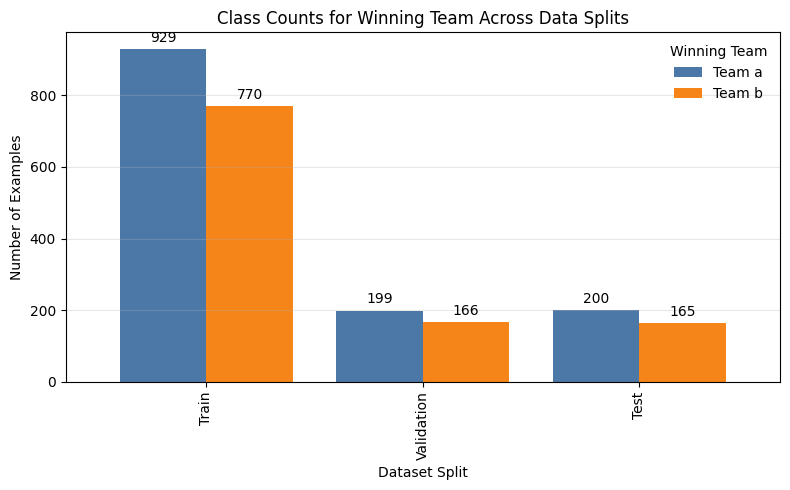

In [60]:
split_counts = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts().sort_index(),
    "Validation": pd.Series(y_val).value_counts().sort_index(),
    "Test": pd.Series(y_test).value_counts().sort_index(),
}).fillna(0).astype(int)

idx_to_label = {idx: label for label, idx in label_map.items()}
split_counts.index = [f"Team {idx_to_label[idx]}" for idx in split_counts.index]

ax = split_counts.T.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.8,
    color=["#4C78A8", "#F58518"],
)

ax.set_title("Class Counts for Winning Team Across Data Splits")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Examples")
ax.legend(title="Winning Team", frameon=False)
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()


In [61]:
BATCH_SIZE = 64

train_ds = TensorDataset(
    torch.tensor(X_train_np, dtype=torch.float32),
    torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1),
)
val_ds = TensorDataset(
    torch.tensor(X_val_np, dtype=torch.float32),
    torch.tensor(y_val_np, dtype=torch.float32).unsqueeze(1),
)
test_ds = TensorDataset(
    torch.tensor(X_test_np, dtype=torch.float32),
    torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


class RallyOutcomeMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model = RallyOutcomeMLP(X_train_np.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model


RallyOutcomeMLP(
  (net): Sequential(
    (0): Linear(in_features=379, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [62]:
def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    all_probs = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * xb.size(0)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    probs = np.vstack(all_probs).ravel()
    targets = np.vstack(all_targets).ravel()
    preds = (probs >= threshold).astype(int)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(targets, preds),
        "auc": roc_auc_score(targets, probs),
        "confusion_matrix": confusion_matrix(targets, preds),
        "probs": probs,
        "targets": targets,
    }


EPOCHS = 30
best_val_auc = -np.inf
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    train_probs = []
    train_targets = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_targets.append(yb.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_probs = np.vstack(train_probs).ravel()
    train_targets = np.vstack(train_targets).ravel()
    train_preds = (train_probs >= 0.5).astype(int)
    train_accuracy = accuracy_score(train_targets, train_preds)

    val_metrics = evaluate_model(model, val_loader)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_auc": val_metrics["auc"],
    })

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc']:.4f}"
        )

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()


Epoch 01 | train_loss=0.6894 | train_acc=0.5397 | val_loss=0.6852 | val_acc=0.5452 | val_auc=0.6120
Epoch 05 | train_loss=0.5649 | train_acc=0.7081 | val_loss=0.6440 | val_acc=0.6384 | val_auc=0.6719
Epoch 10 | train_loss=0.2791 | train_acc=0.8999 | val_loss=0.7233 | val_acc=0.6630 | val_auc=0.7181
Epoch 15 | train_loss=0.1306 | train_acc=0.9641 | val_loss=0.9944 | val_acc=0.6521 | val_auc=0.6955
Epoch 20 | train_loss=0.0604 | train_acc=0.9865 | val_loss=1.1660 | val_acc=0.6329 | val_auc=0.7057
Epoch 25 | train_loss=0.0372 | train_acc=0.9900 | val_loss=1.2902 | val_acc=0.6438 | val_auc=0.7034
Epoch 30 | train_loss=0.0309 | train_acc=0.9894 | val_loss=1.4319 | val_acc=0.6493 | val_auc=0.6952


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_auc
25,26,0.030366,0.992937,1.305147,0.654795,0.711267
26,27,0.032812,0.992937,1.403805,0.657534,0.701277
27,28,0.031097,0.992937,1.378133,0.665753,0.708482
28,29,0.036013,0.988817,1.404675,0.646575,0.699068
29,30,0.030903,0.989406,1.431871,0.649315,0.695163


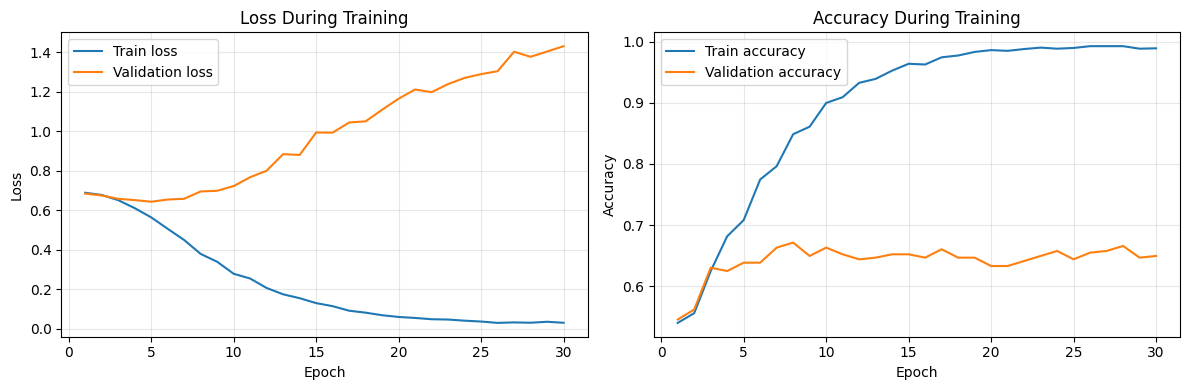

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
axes[0].set_title("Loss During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Accuracy During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [64]:
val_results = evaluate_model(model, val_loader)
test_results = evaluate_model(model, test_loader)

print("Validation metrics")
print(f"  Loss     : {val_results['loss']:.4f}")
print(f"  Accuracy : {val_results['accuracy']:.4f}")
print(f"  ROC-AUC  : {val_results['auc']:.4f}")
print("  Confusion matrix:")
print(val_results["confusion_matrix"])

print("\nTest metrics")
print(f"  Loss     : {test_results['loss']:.4f}")
print(f"  Accuracy : {test_results['accuracy']:.4f}")
print(f"  ROC-AUC  : {test_results['auc']:.4f}")
print("  Confusion matrix:")
print(test_results["confusion_matrix"])


Validation metrics
  Loss     : 0.7233
  Accuracy : 0.6630
  ROC-AUC  : 0.7181
  Confusion matrix:
[[148  51]
 [ 72  94]]

Test metrics
  Loss     : 0.6605
  Accuracy : 0.6986
  ROC-AUC  : 0.7514
  Confusion matrix:
[[153  47]
 [ 63 102]]
